**Motorcycle Recommender System ด้วย Graph** <br>แนวคิดคือ ผู้ใช้ชอบหรือสนใจรถมอเตอร์ไซค์รุ่นไหน → หา User คนอื่นที่ชอบรถมอเตอร์ไซค์คล้ายกัน → ดูว่าคนเหล่านั้นชอบรถมอเตอร์ไซค์รุ่นอะไรอีก → แนะนำรถมอเตอร์ไซค์รุ่นนั้นกลับมา

ตัวอย่างสถานการณ์ มีผู้ใช้ 10 คน <br>

```
Mint
Non
Fah
Ton
Aom
Boss
Jane
Kit
May
Palm
```

และมีรถมอเตอร์ไซค์

```
Honda CB150R
Yamaha MT-15
Kawasaki Ninja 400
Vespa Primavera
GPX Drone
Honda Click 160
Yamaha XMAX
Kawasaki Z650
Suzuki GSX-R150
Royal Enfield Classic 350
```

สมมติข้อมูลความชอบคือ

```
Mint   → Honda CB150R
Mint   → Yamaha MT-15

Non     → Honda CB150R
Non     → Yamaha MT-15
Non     → Vespa Primavera

Fah → Honda CB150R
Fah → Kawasaki Ninja 400

Ton   → Vespa Primavera
Ton   → GPX Drone
```



```
เราจะสังเกตได้ว่า

Mint และ Non ชอบ Honda CB150R และ Yamaha MT-15 เหมือนกัน

แต่ Non ยังชอบ

Vespa Primavera

ดังนั้นระบบสามารถคิดง่าย ๆ ว่า

ถ้า Mint กับ Non มีความชอบคล้ายกัน
และ Non ชอบ Vespa Primavera แต่ Mint ยังไม่ได้เลือก Vespa Primavera
ระบบอาจแนะนำ Vespa Primavera ให้ Mint

นี่คือ Recommender System แบบ Graph อย่างง่ายค่ะ
```



การออกแบบ Graph

```
เราแบ่ง Node เป็น 2 ประเภท

User
Motorcycle

Relationship คือ

LIKES

ดังนั้น

(User)-[:LIKES]->(Motorcycle)

เช่น

(Mint)-[:LIKES]->(Honda CB150R)

หรือถ้าเป็น Python NetworkX

G.add_edge("Mint", "Honda CB150R")
```


**สร้างด้วย Python บน Google Colab**

In [ ]:
!pip -q install networkx

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
G = nx.Graph()

In [ ]:
#add user
users = [
    "Mint", "Non", "Fah", "Ton", "Aom",
    "Boss", "Jane", "Kit", "May", "Palm"
]

for user in users:
    G.add_node(
        user,
        node_type="user"
    )

In [ ]:
#add motorcycles
motorcycles = [
    "Honda CB150R", "Yamaha MT-15", "Kawasaki Ninja 400",
    "Vespa Primavera", "GPX Drone", "Honda Click 160",
    "Yamaha XMAX", "Kawasaki Z650", "Suzuki GSX-R150", "Royal Enfield Classic 350"
]

for motorcycle in motorcycles:
    G.add_node(
        motorcycle,
        node_type="motorcycle"
    )

In [ ]:
#add relationship
likes = [
    ("Mint", "Honda CB150R"), ("Mint", "Yamaha MT-15"),
    ("Non", "Honda CB150R"), ("Non", "Yamaha MT-15"), ("Non", "Vespa Primavera"),
    ("Fah", "Honda CB150R"), ("Fah", "Kawasaki Ninja 400"),
    ("Ton", "Vespa Primavera"), ("Ton", "GPX Drone"),
    ("Aom", "Honda Click 160"), ("Aom", "Yamaha XMAX"),
    ("Boss", "Kawasaki Z650"), ("Boss", "Suzuki GSX-R150"),
    ("Jane", "Honda Click 160"), ("Jane", "Royal Enfield Classic 350"),
    ("Kit", "Yamaha XMAX"), ("Kit", "Kawasaki Z650"),
    ("May", "Suzuki GSX-R150"), ("May", "Honda CB150R"),
    ("Palm", "Royal Enfield Classic 350"), ("Palm", "GPX Drone")
]

เพิ่มเข้า Graph

In [ ]:
G.add_edges_from(likes)

วาด Graph

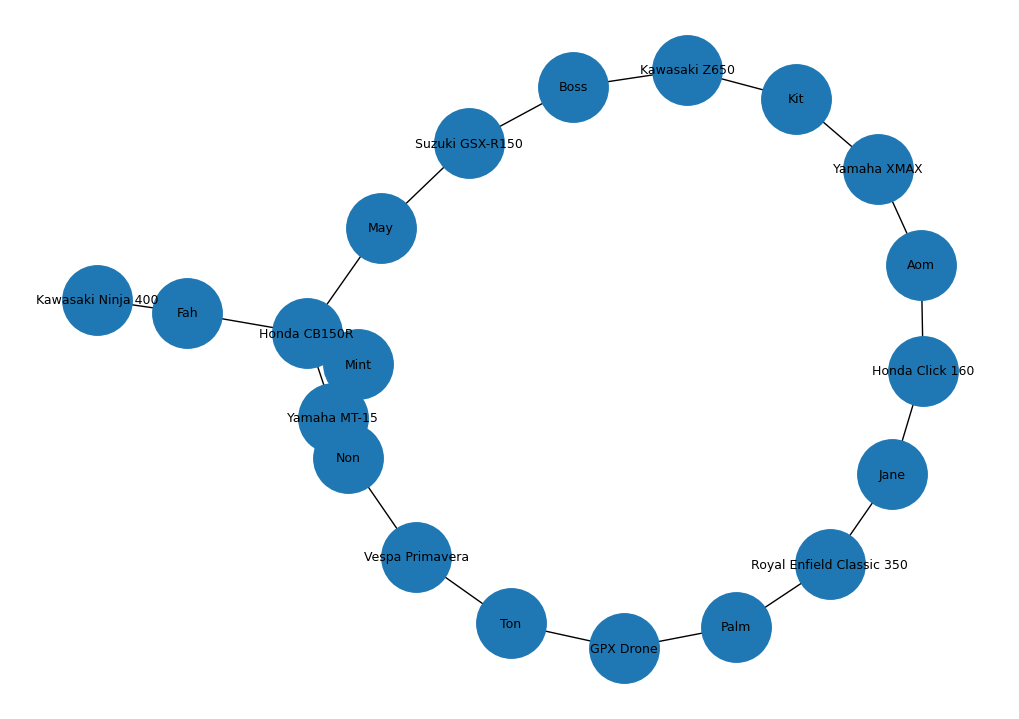

In [ ]:
plt.figure(figsize=(10, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า Mint ชอบรถมอเตอร์ไซค์รุ่นอะไรบ้าง?

In [ ]:
kanya_motorcycles = list(
    G.neighbors("Mint")
)

print(kanya_motorcycles)

['Honda CB150R', 'Yamaha MT-15']


ตรงนี้อธิบายได้ว่า Neighbor ของ Mint คือ Node ที่เชื่อมกับ Mint

คำถามที่ 2. หา User ที่ชอบรถมอเตอร์ไซค์เหมือน Mint <br>
Mint ชอบ  Honda CB150R  Yamaha MT-15 <br>
เราสามารถหาได้ว่าใครชอบรถมอเตอร์ไซค์เหล่านี้เหมือนกัน

In [ ]:
for motorcycle in G.neighbors("Non"):

    print("Motorcycle:", motorcycle)

    for user in G.neighbors(motorcycle):

        if user != "Non":
            print("  Similar user:", user)

Motorcycle: Honda CB150R
  Similar user: Mint
  Similar user: Fah
  Similar user: May
Motorcycle: Yamaha MT-15
  Similar user: Mint
Motorcycle: Vespa Primavera
  Similar user: Ton


**สร้าง Recommendation แบบง่าย**

```
แนวคิดคือ

Mint
 ↓
รถมอเตอร์ไซค์ที่ Mint ชอบ
 ↓
User ที่ชอบรถมอเตอร์ไซค์รุ่นเดียวกัน
 ↓
รถมอเตอร์ไซค์รุ่นอื่นที่ User เหล่านั้นชอบ
 ↓
แนะนำให้ Mint
```



In [ ]:
from collections import Counter


target_user = "Mint"

recommendations = Counter()


# รถมอเตอร์ไซค์ที่ Mint ชอบแล้ว
liked_motorcycles = set(
    G.neighbors(target_user)
)


# ดูรถมอเตอร์ไซค์แต่ละยี่ห้อที่ Mint ชอบ
for motorcycle in liked_motorcycles:

    # หา User ที่ชอบรถมอเตอร์ไซค์รุ่นเดียวกัน
    for similar_user in G.neighbors(motorcycle):

        if similar_user == target_user:
            continue #ไม่เอาตัวเองมาคำนวณ

        # ดูว่า User คนนั้นชอบรถมอเตอร์ไซค์รุ่นอะไรอีก
        for other_motorcycle in G.neighbors(similar_user):

            # Mint ยังไม่เคยชอบเรื่องนี้
            if other_motorcycle not in liked_motorcycles:

                recommendations[other_motorcycle] += 1


print(recommendations)

Counter({'Vespa Primavera': 2, 'Kawasaki Ninja 400': 1, 'Suzuki GSX-R150': 1})


Kawasaki Ninja 400 ถูกพบจาก User ที่มีความสัมพันธ์กับ Mint จำนวน 1 ครั้ง

In [ ]:
# นำไปสร้างเป็นฟังก์ชัน

In [ ]:
from collections import Counter


def recommend_motorcycles(G, target_user):

    recommendations = Counter()

    liked_motorcycles = set(
        G.neighbors(target_user)
    )

    for motorcycle in liked_motorcycles:

        for similar_user in G.neighbors(motorcycle):

            if similar_user == target_user:
                continue

            for other_motorcycle in G.neighbors(similar_user):

                if other_motorcycle not in liked_motorcycles:

                    recommendations[other_motorcycle] += 1

    return recommendations.most_common()

In [ ]:
#เรียกใช้งาน
result = recommend_motorcycles( G, "Mint")
print(result)

[('Vespa Primavera', 2), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_motorcycles( G, "Fah")
print(result)

[('Yamaha MT-15', 2), ('Vespa Primavera', 1), ('Suzuki GSX-R150', 1)]


In [ ]:
#เรียกใช้งาน
result = recommend_motorcycles( G, "Non")
print(result)

[('GPX Drone', 1), ('Kawasaki Ninja 400', 1), ('Suzuki GSX-R150', 1)]


In [ ]:
kanya_motorcycles = list(
    G.neighbors("Mint")
)

print(kanya_motorcycles)

['Honda CB150R', 'Yamaha MT-15']


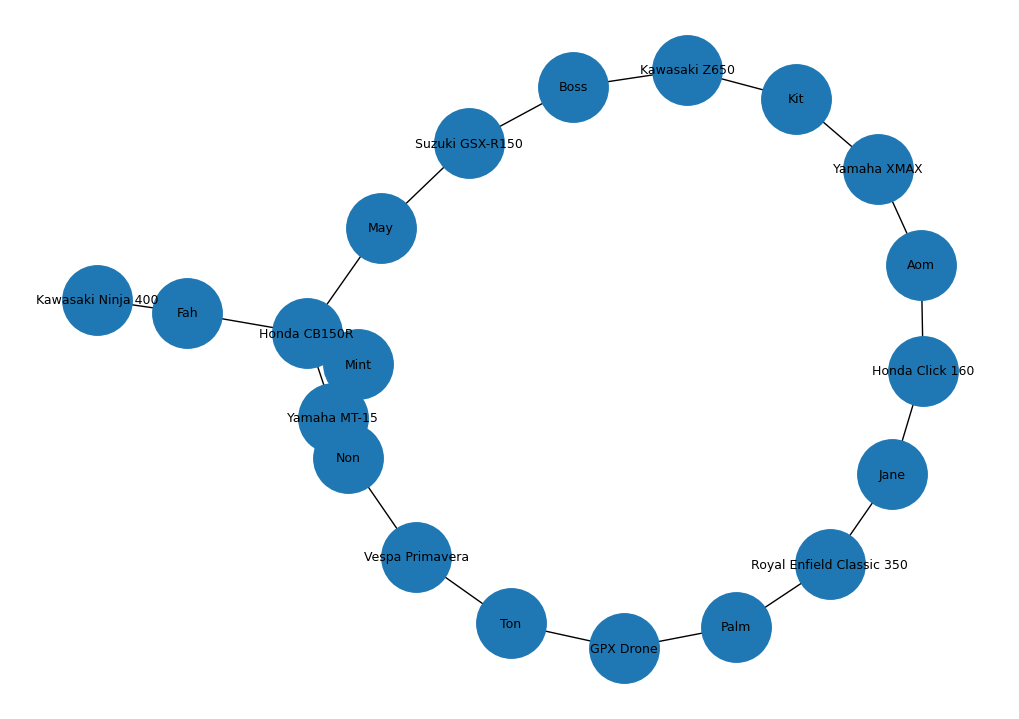

Recommendations for May
Yamaha MT-15 Score = 2
Kawasaki Z650 Score = 1
Vespa Primavera Score = 1
Kawasaki Ninja 400 Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "Mint", "Non", "Fah", "Ton", "Aom",
    "Boss", "Jane", "Kit", "May", "Palm"
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Motorcycles
# ==================================

motorcycles = [
    "Honda CB150R", "Yamaha MT-15", "Kawasaki Ninja 400",
    "Vespa Primavera", "GPX Drone", "Honda Click 160",
    "Yamaha XMAX", "Kawasaki Z650", "Suzuki GSX-R150", "Royal Enfield Classic 350"
]

for motorcycle in motorcycles:

    G.add_node(
        motorcycle,
        node_type="motorcycle"
    )


# ==================================
# 4. User-Motorcycle Relationships
# ==================================

likes = [

    ("Mint", "Honda CB150R"),
    ("Mint", "Yamaha MT-15"),

    ("Non", "Honda CB150R"),
    ("Non", "Yamaha MT-15"),
    ("Non", "Vespa Primavera"),

    ("Fah", "Honda CB150R"),
    ("Fah", "Kawasaki Ninja 400"),

    ("Ton", "Vespa Primavera"),
    ("Ton", "GPX Drone"),

    ("Aom", "Honda Click 160"),
    ("Aom", "Yamaha XMAX"),
    ("Boss", "Kawasaki Z650"),
    ("Boss", "Suzuki GSX-R150"),
    ("Jane", "Honda Click 160"),
    ("Jane", "Royal Enfield Classic 350"),
    ("Kit", "Yamaha XMAX"),
    ("Kit", "Kawasaki Z650"),
    ("May", "Suzuki GSX-R150"),
    ("May", "Honda CB150R"),
    ("Palm", "Royal Enfield Classic 350"),
    ("Palm", "GPX Drone")

]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(10, 7) #กำหนดขนาดรูปภาพ
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_motorcycles(
    G,
    target_user #หารถที่ผู้ใช้ชอบอยู๋แล้ว
):#สร้างฟังช์ชื่อ

    recommendations = Counter() #สร้าง Counter เพื่อเก็บคะแนนของรถแต่ละรุ่น

    liked_motorcycles = set(
        G.neighbors(
            target_user
        ) #ดูว่า Node นี้เชื่อมต่อกับใครบ้าง
    )
#  หา User คนอื่นที่ชอบรถแบบเดียวกัน
    for motorcycle in liked_motorcycles: #วนดูรถที่ Target User ชอบทีละคัน

        for similar_user in G.neighbors(motorcycle): #ดูว่า มี User คนไหนอีกบ้างที่ชอบรถคันนี้

            if similar_user == target_user:
                continue #ไม่เอาตัวเองมาคำนวณ

            for other_motorcycle in G.neighbors(
                similar_user
            ): #ดูว่าผู้ใช้ที่คล้ายกันชอบรถอะไรอีก

                if other_motorcycle not in liked_motorcycles:

                    recommendations[
                        other_motorcycle
                    ] += 1 #ถ้าเจอรถที่ผู้ใช้คล้ายกันชอบ ก็เพิ่มคะแนนให้รถนั้น +1

    return recommendations.most_common()


# ==================================
# 7. Recommend for May
# ==================================

target_user = "May" #กำหนดว่าเราต้องการแนะนำรถให้

result = recommend_motorcycles(
    G,
    target_user
) #เรียกฟังก์ชัน Recommendation


print(
    "Recommendations for",
    target_user
)


for motorcycle, score in result:

    print(
        motorcycle,
        "Score =",
        score
    )

Recommender System แบบ Graph ไม่ได้มองเพียงว่า “รถมอเตอร์ไซค์รุ่นไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และรถมอเตอร์ไซค์รุ่นอื่นอย่างไร”